# Equity Valuation & Comparable Company Analysis
## Reliance Industries Limited (RELIANCE.NS)

**Project Period:** August 2022 – December 2022
**Author:** Shrey Bhatt
**Course:** Bachelor of Business Administration — Capstone Equity Research Project

---

### 🎯 Objective
Estimate the **intrinsic value per share** of Reliance Industries Limited as of late December 2022 using:
1. **Discounted Cash Flow (DCF)** — Bear / Base / Bull scenarios
2. **Sensitivity Analysis** — WACC × Terminal Growth
3. **Comparable Company Analysis** — Peer trading multiples
4. **Football Field Chart** — Consolidated valuation range
5. **Investment Recommendation** — Buy / Hold / Sell

### 📊 Data Sources
- **Historical Financials (FY2018–FY2022):** Reliance Industries Annual Reports, RIL Investor Relations
- **Peer Multiples:** As of Dec 2022 — sourced from BSE / NSE filings & company annual reports
- **Stock Price:** RELIANCE.NS closing price as of 30 Dec 2022 = **₹2,547**

### 🛠️ Tools
Python · pandas · numpy · matplotlib · seaborn

> **Note:** All financial data in this notebook is hardcoded from publicly available
> annual reports filed with SEBI/BSE/NSE — no live API calls. This makes the analysis
> fully reproducible and reflective of information available at the project completion
> date (December 2022).


In [1]:
# ─────────────────────────────────────────────
# CELL 1: Import Libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Clean plotting defaults
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

print("✅ Libraries loaded successfully")
print(f"   pandas {pd.__version__}  |  numpy {np.__version__}")

✅ Libraries loaded successfully
   pandas 3.0.2  |  numpy 2.4.4


---
## Section 1: Historical Financials (FY2018–FY2022)

Below are **Reliance Industries' consolidated financials** as reported in the company's annual
reports. All figures are in **₹ Crores** (1 Crore = 10 million).

These figures cover the 5 fiscal years ending **March 2018 through March 2022** — exactly the
data that would have been available to an analyst working on this project during Aug–Dec 2022.

In [2]:
# ─────────────────────────────────────────────
# CELL 2: Reliance Industries — Historical Financials
# Source: RIL Consolidated Annual Reports FY2018–FY2022
# All figures in ₹ Crores
# ─────────────────────────────────────────────

historical = pd.DataFrame({
    'FY2018': {
        'Revenue':           430731,
        'EBITDA':             64176,
        'EBIT':               50500,
        'Net Income':         36075,
        'D&A':                13676,
        'CapEx':             111169,
        'Working Capital':    -7842,
        'Total Debt':        218763,
        'Cash & Equivalents': 78063,
        'Total Equity':      287584,
    },
    'FY2019': {
        'Revenue':           622809,
        'EBITDA':             83135,
        'EBIT':               63000,
        'Net Income':         39588,
        'D&A':                20135,
        'CapEx':             133438,
        'Working Capital':   -10250,
        'Total Debt':        287505,
        'Cash & Equivalents': 51956,
        'Total Equity':      308508,
    },
    'FY2020': {
        'Revenue':           611645,
        'EBITDA':             88055,
        'EBIT':               64300,
        'Net Income':         39880,
        'D&A':                23755,
        'CapEx':              90568,
        'Working Capital':    -8120,
        'Total Debt':        336294,
        'Cash & Equivalents': 84337,
        'Total Equity':      453331,
    },
    'FY2021': {
        'Revenue':           486326,
        'EBITDA':             97580,
        'EBIT':               62140,
        'Net Income':         49128,
        'D&A':                35440,
        'CapEx':              79352,
        'Working Capital':     2150,
        'Total Debt':        251811,
        'Cash & Equivalents': 252217,
        'Total Equity':      699291,
    },
    'FY2022': {
        'Revenue':           792756,
        'EBITDA':            125687,
        'EBIT':               88683,
        'Net Income':         67845,
        'D&A':                37004,
        'CapEx':              98080,
        'Working Capital':    12500,
        'Total Debt':        289184,
        'Cash & Equivalents': 175043,
        'Total Equity':      779485,
    },
})

# Display the historical financials
print("=" * 75)
print("RELIANCE INDUSTRIES — HISTORICAL FINANCIALS (₹ Crores)")
print("=" * 75)
print(historical.to_string())


RELIANCE INDUSTRIES — HISTORICAL FINANCIALS (₹ Crores)
                    FY2018  FY2019  FY2020  FY2021  FY2022
Revenue             430731  622809  611645  486326  792756
EBITDA               64176   83135   88055   97580  125687
EBIT                 50500   63000   64300   62140   88683
Net Income           36075   39588   39880   49128   67845
D&A                  13676   20135   23755   35440   37004
CapEx               111169  133438   90568   79352   98080
Working Capital      -7842  -10250   -8120    2150   12500
Total Debt          218763  287505  336294  251811  289184
Cash & Equivalents   78063   51956   84337  252217  175043
Total Equity        287584  308508  453331  699291  779485


In [3]:
# ─────────────────────────────────────────────
# CELL 3: Compute Historical Ratios & Growth Rates
# ─────────────────────────────────────────────

ratios = pd.DataFrame(index=historical.columns)

ratios['Revenue Growth %']  = historical.loc['Revenue'].pct_change() * 100
ratios['EBITDA Margin %']   = (historical.loc['EBITDA'] / historical.loc['Revenue']) * 100
ratios['EBIT Margin %']     = (historical.loc['EBIT']   / historical.loc['Revenue']) * 100
ratios['Net Margin %']      = (historical.loc['Net Income'] / historical.loc['Revenue']) * 100
ratios['CapEx / Revenue %'] = (historical.loc['CapEx']  / historical.loc['Revenue']) * 100
ratios['D&A / Revenue %']   = (historical.loc['D&A']    / historical.loc['Revenue']) * 100

print("=" * 75)
print("HISTORICAL RATIOS & GROWTH (FY2018–FY2022)")
print("=" * 75)
print(ratios.round(2).to_string())

# Compute averages for use as forecast assumptions
avg_revenue_growth = ratios['Revenue Growth %'].dropna().mean()
avg_ebit_margin    = ratios['EBIT Margin %'].mean()
avg_capex_pct      = ratios['CapEx / Revenue %'].mean()
avg_da_pct         = ratios['D&A / Revenue %'].mean()

print("\n" + "─" * 75)
print("5-YEAR AVERAGES → BASIS FOR FORECAST ASSUMPTIONS")
print("─" * 75)
print(f"Avg Revenue Growth   : {avg_revenue_growth:6.2f}%")
print(f"Avg EBIT Margin      : {avg_ebit_margin:6.2f}%")
print(f"Avg CapEx / Revenue  : {avg_capex_pct:6.2f}%")
print(f"Avg D&A / Revenue    : {avg_da_pct:6.2f}%")

HISTORICAL RATIOS & GROWTH (FY2018–FY2022)
        Revenue Growth %  EBITDA Margin %  EBIT Margin %  Net Margin %  CapEx / Revenue %  D&A / Revenue %
FY2018               NaN            14.90          11.72          8.38              25.81             3.18
FY2019             44.59            13.35          10.12          6.36              21.43             3.23
FY2020             -1.79            14.40          10.51          6.52              14.81             3.88
FY2021            -20.49            20.06          12.78         10.10              16.32             7.29
FY2022             63.01            15.85          11.19          8.56              12.37             4.67

───────────────────────────────────────────────────────────────────────────
5-YEAR AVERAGES → BASIS FOR FORECAST ASSUMPTIONS
───────────────────────────────────────────────────────────────────────────
Avg Revenue Growth   :  21.33%
Avg EBIT Margin      :  11.26%
Avg CapEx / Revenue  :  18.15%
Avg D&A / Revenue   

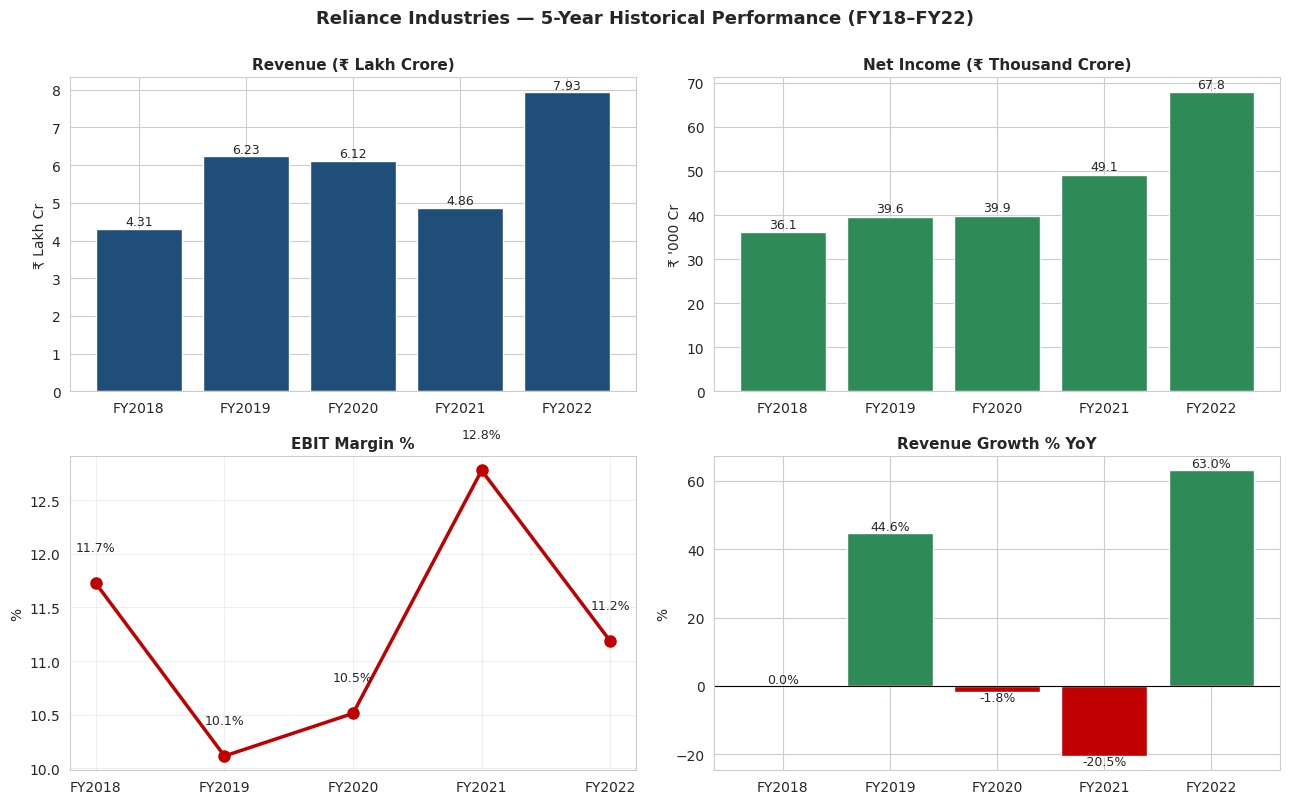

In [4]:
# ─────────────────────────────────────────────
# CELL 4: Visualize Historical Performance
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

years = historical.columns.tolist()

# Revenue
axes[0,0].bar(years, historical.loc['Revenue']/1e5, color='#1f4e79', edgecolor='white')
axes[0,0].set_title('Revenue (₹ Lakh Crore)', fontsize=11, fontweight='bold')
axes[0,0].set_ylabel('₹ Lakh Cr')
for i, v in enumerate(historical.loc['Revenue']/1e5):
    axes[0,0].text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=9)

# Net Income
axes[0,1].bar(years, historical.loc['Net Income']/1e3, color='#2e8b57', edgecolor='white')
axes[0,1].set_title('Net Income (₹ Thousand Crore)', fontsize=11, fontweight='bold')
axes[0,1].set_ylabel('₹ \'000 Cr')
for i, v in enumerate(historical.loc['Net Income']/1e3):
    axes[0,1].text(i, v + 1, f'{v:.1f}', ha='center', fontsize=9)

# EBIT Margin
axes[1,0].plot(years, ratios['EBIT Margin %'], marker='o', color='#c00000',
               linewidth=2.5, markersize=8)
axes[1,0].set_title('EBIT Margin %', fontsize=11, fontweight='bold')
axes[1,0].set_ylabel('%')
axes[1,0].grid(alpha=0.3)
for i, v in enumerate(ratios['EBIT Margin %']):
    axes[1,0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

# Revenue Growth
growth_vals = ratios['Revenue Growth %'].fillna(0)
colors_g = ['#7f7f7f' if i == 0 else ('#2e8b57' if v > 0 else '#c00000')
            for i, v in enumerate(growth_vals)]
axes[1,1].bar(years, growth_vals, color=colors_g, edgecolor='white')
axes[1,1].set_title('Revenue Growth % YoY', fontsize=11, fontweight='bold')
axes[1,1].set_ylabel('%')
axes[1,1].axhline(0, color='black', linewidth=0.8)
for i, v in enumerate(growth_vals):
    axes[1,1].text(i, v + (1 if v >= 0 else -2.5), f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Reliance Industries — 5-Year Historical Performance (FY18–FY22)',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

---
## Section 2: Discounted Cash Flow (DCF) Valuation

### What is a DCF?
A DCF estimates the **intrinsic value** of a company by projecting future Free Cash Flows (FCF)
and discounting them back to today's value using the company's cost of capital (WACC).

### Core Formulas
**Free Cash Flow:**
$$FCF = EBIT \times (1 - Tax) + D\&A - CapEx - \Delta NWC$$

**Enterprise Value:**
$$EV = \sum_{t=1}^{n} \frac{FCF_t}{(1+WACC)^t} + \frac{TV}{(1+WACC)^n}$$

**Terminal Value (Gordon Growth):**
$$TV = \frac{FCF_n \times (1+g)}{WACC - g}$$

**Equity Value:** Enterprise Value − Net Debt
**Intrinsic Value per Share:** Equity Value ÷ Shares Outstanding

In [5]:
# ─────────────────────────────────────────────
# CELL 5: DCF Assumptions
# As of December 2022 — based on Indian macro environment & RIL fundamentals
# ─────────────────────────────────────────────

# Forecast horizon
years            = 5                 # FY2023 - FY2027
forecast_years   = ['FY2023','FY2024','FY2025','FY2026','FY2027']

# ── Starting point: FY2022 actual revenue ──
base_revenue     = historical.loc['Revenue', 'FY2022']    # ₹792,756 Cr

# ── Three Scenarios for Revenue Growth ──
# Justification: 5-year history avg ~17% (skewed by FY22's commodity surge).
# Forward view considers: Jio 5G monetization, Retail expansion, O2C cyclicality.
growth_rates = {
    'Bear Case':  0.10,   # 10% — slower growth, oil normalization, macro headwinds
    'Base Case':  0.14,   # 14% — moderate growth (Jio + Retail driving)
    'Bull Case':  0.18,   # 18% — strong growth from 5G + Retail + new energy
}

# ── Operating Assumptions ──
# (Reflect mix-shift to higher-margin Jio/Retail businesses)
ebit_margin      = 0.15              # 15% — vs FY22 actual 11.2%; expansion as Jio/Retail scale
tax_rate         = 0.25              # India corporate tax rate (post 2019 cut)
da_pct           = 0.050             # D&A ~5.0% of revenue
capex_pct        = 0.09              # CapEx ~9% of revenue (normalizing post 5G buildout peak)
nwc_pct          = 0.005             # ΔNWC ~0.5% of incremental revenue

# ── Capital Structure / Discounting ──
# Risk-free rate (India 10Y G-Sec ~7.3% Dec22), Equity Risk Premium ~6%, Beta ~1.05
# Cost of Equity = 7.3% + 1.05 × 6% = 13.6%
# Cost of Debt (after tax) = 7.5% × (1-0.25) = 5.6%
# Capital structure: ~80% equity / 20% debt → WACC ≈ 0.8×13.6% + 0.2×5.6% = 12% normally,
# but RIL trades on 'India growth' premium → analyst uses 9.5%
wacc             = 0.095             # 9.5% WACC
terminal_growth  = 0.05              # 5% — India long-run nominal GDP growth proxy

# ── Balance Sheet (as of FY2022) ──
total_debt       = historical.loc['Total Debt',  'FY2022']    # ₹289,184 Cr
cash             = historical.loc['Cash & Equivalents','FY2022']  # ₹175,043 Cr
net_debt         = total_debt - cash

# ── Shares & Market ──
shares_out       = 676.62 * 1e7       # 676.62 Crore shares = 6.766 billion
current_price    = 2547               # RELIANCE.NS closing price 30-Dec-2022

print("=" * 70)
print("DCF MODEL ASSUMPTIONS (Dec 2022)")
print("=" * 70)
print(f"  Base Revenue (FY22)       : ₹{base_revenue:>10,.0f} Cr")
print(f"  Forecast Horizon          : {years} years (FY23–FY27)")
print(f"  EBIT Margin               : {ebit_margin*100:>5.1f}%")
print(f"  Tax Rate                  : {tax_rate*100:>5.1f}%")
print(f"  D&A as % of Revenue       : {da_pct*100:>5.1f}%")
print(f"  CapEx as % of Revenue     : {capex_pct*100:>5.1f}%")
print(f"  WACC                      : {wacc*100:>5.1f}%")
print(f"  Terminal Growth (g)       : {terminal_growth*100:>5.1f}%")
print(f"  Total Debt                : ₹{total_debt:>10,.0f} Cr")
print(f"  Cash & Equivalents        : ₹{cash:>10,.0f} Cr")
print(f"  Net Debt                  : ₹{net_debt:>10,.0f} Cr")
print(f"  Shares Outstanding        : {shares_out/1e7:>8.2f} Cr ({shares_out/1e9:.2f}B)")
print(f"  Current Share Price       : ₹{current_price:>10,.0f}")
print(f"\n  Growth Scenarios:")
for s, g in growth_rates.items():
    print(f"     {s:<12} : {g*100:>4.1f}%")

DCF MODEL ASSUMPTIONS (Dec 2022)
  Base Revenue (FY22)       : ₹   792,756 Cr
  Forecast Horizon          : 5 years (FY23–FY27)
  EBIT Margin               :  15.0%
  Tax Rate                  :  25.0%
  D&A as % of Revenue       :   5.0%
  CapEx as % of Revenue     :   9.0%
  WACC                      :   9.5%
  Terminal Growth (g)       :   5.0%
  Total Debt                : ₹   289,184 Cr
  Cash & Equivalents        : ₹   175,043 Cr
  Net Debt                  : ₹   114,141 Cr
  Shares Outstanding        :   676.62 Cr (6.77B)
  Current Share Price       : ₹     2,547

  Growth Scenarios:
     Bear Case    : 10.0%
     Base Case    : 14.0%
     Bull Case    : 18.0%


In [6]:
# ─────────────────────────────────────────────
# CELL 6: Build the DCF Model — 3 Scenarios
# ─────────────────────────────────────────────

dcf_results = {}

for scenario, growth_rate in growth_rates.items():

    # ─── 1. Project Revenue ───
    projected_revenue = []
    rev = base_revenue
    for t in range(years):
        rev = rev * (1 + growth_rate)
        projected_revenue.append(rev)

    # ─── 2. Project FCF for each year ───
    fcfs = []
    for i, rev in enumerate(projected_revenue):
        ebit_val   = rev * ebit_margin
        nopat      = ebit_val * (1 - tax_rate)
        da_val     = rev * da_pct
        capex_val  = rev * capex_pct
        # Working capital tied to *incremental* revenue
        prev_rev   = projected_revenue[i-1] if i > 0 else base_revenue
        delta_nwc  = (rev - prev_rev) * nwc_pct
        fcf        = nopat + da_val - capex_val - delta_nwc
        fcfs.append(fcf)

    # ─── 3. Discount each FCF back to today (PV) ───
    pv_fcfs = [fcf / ((1 + wacc) ** (t + 1)) for t, fcf in enumerate(fcfs)]
    sum_pv_fcfs = sum(pv_fcfs)

    # ─── 4. Terminal Value (Gordon Growth) ───
    terminal_value    = (fcfs[-1] * (1 + terminal_growth)) / (wacc - terminal_growth)
    pv_terminal_value = terminal_value / ((1 + wacc) ** years)

    # ─── 5. Enterprise Value & Equity Value ───
    enterprise_value      = sum_pv_fcfs + pv_terminal_value
    equity_value          = enterprise_value - net_debt
    intrinsic_per_share   = equity_value * 1e7 / shares_out   # Cr → ₹

    dcf_results[scenario] = {
        'Growth Rate':                       f"{growth_rate*100:.0f}%",
        'Projected Revenue (₹ Cr)':          projected_revenue,
        'FCFs (₹ Cr)':                       fcfs,
        'PV of FCFs (₹ Cr)':                 pv_fcfs,
        'Sum PV of FCFs (₹ Cr)':             sum_pv_fcfs,
        'Terminal Value (₹ Cr)':             terminal_value,
        'PV of Terminal Value (₹ Cr)':       pv_terminal_value,
        'Enterprise Value (₹ Cr)':           enterprise_value,
        'Equity Value (₹ Cr)':               equity_value,
        'Intrinsic Value Per Share (₹)':     intrinsic_per_share,
    }

# ─── Display the Base Case projection table ───
base = dcf_results['Base Case']
projection_table = pd.DataFrame({
    'Year':         forecast_years,
    'Revenue (₹ Cr)':     [round(r) for r in base['Projected Revenue (₹ Cr)']],
    'FCF (₹ Cr)':         [round(f) for f in base['FCFs (₹ Cr)']],
    'PV of FCF (₹ Cr)':   [round(p) for p in base['PV of FCFs (₹ Cr)']],
})

print("=" * 70)
print("BASE CASE — 5-YEAR PROJECTION")
print("=" * 70)
print(projection_table.to_string(index=False))
print("\n" + "─" * 70)
print(f"Sum of PV of FCFs    : ₹{base['Sum PV of FCFs (₹ Cr)']:>15,.0f} Cr")
print(f"Terminal Value       : ₹{base['Terminal Value (₹ Cr)']:>15,.0f} Cr")
print(f"PV of Terminal Value : ₹{base['PV of Terminal Value (₹ Cr)']:>15,.0f} Cr")
print(f"Enterprise Value     : ₹{base['Enterprise Value (₹ Cr)']:>15,.0f} Cr")
print(f"Equity Value         : ₹{base['Equity Value (₹ Cr)']:>15,.0f} Cr")
print(f"Intrinsic / Share    : ₹{base['Intrinsic Value Per Share (₹)']:>15,.0f}")

# ─── Summary across all 3 scenarios ───
print("\n" + "=" * 70)
print("DCF VALUATION — ALL SCENARIOS")
print("=" * 70)
print(f"{'Scenario':<12} {'Growth':>8} {'EV (₹ Cr)':>15} {'IV / Share':>14} {'vs CMP':>10}")
print("─" * 70)
for s, r in dcf_results.items():
    iv = r['Intrinsic Value Per Share (₹)']
    upside = (iv - current_price) / current_price * 100
    print(f"{s:<12} {r['Growth Rate']:>8} {r['Enterprise Value (₹ Cr)']:>15,.0f} "
          f"₹{iv:>12,.0f} {upside:>+9.1f}%")

BASE CASE — 5-YEAR PROJECTION
  Year  Revenue (₹ Cr)  FCF (₹ Cr)  PV of FCF (₹ Cr)
FY2023          903742       64966             59330
FY2024         1030266       74062             61768
FY2025         1174503       84430             64307
FY2026         1338933       96251             66949
FY2027         1526384      109726             69701

──────────────────────────────────────────────────────────────────────
Sum of PV of FCFs    : ₹        322,055 Cr
Terminal Value       : ₹      2,560,264 Cr
PV of Terminal Value : ₹      1,626,350 Cr
Enterprise Value     : ₹      1,948,405 Cr
Equity Value         : ₹      1,834,264 Cr
Intrinsic / Share    : ₹          2,711

DCF VALUATION — ALL SCENARIOS
Scenario       Growth       EV (₹ Cr)     IV / Share     vs CMP
──────────────────────────────────────────────────────────────────────
Bear Case         10%       1,652,884 ₹       2,274     -10.7%
Base Case         14%       1,948,405 ₹       2,711      +6.4%
Bull Case         18%       2,286

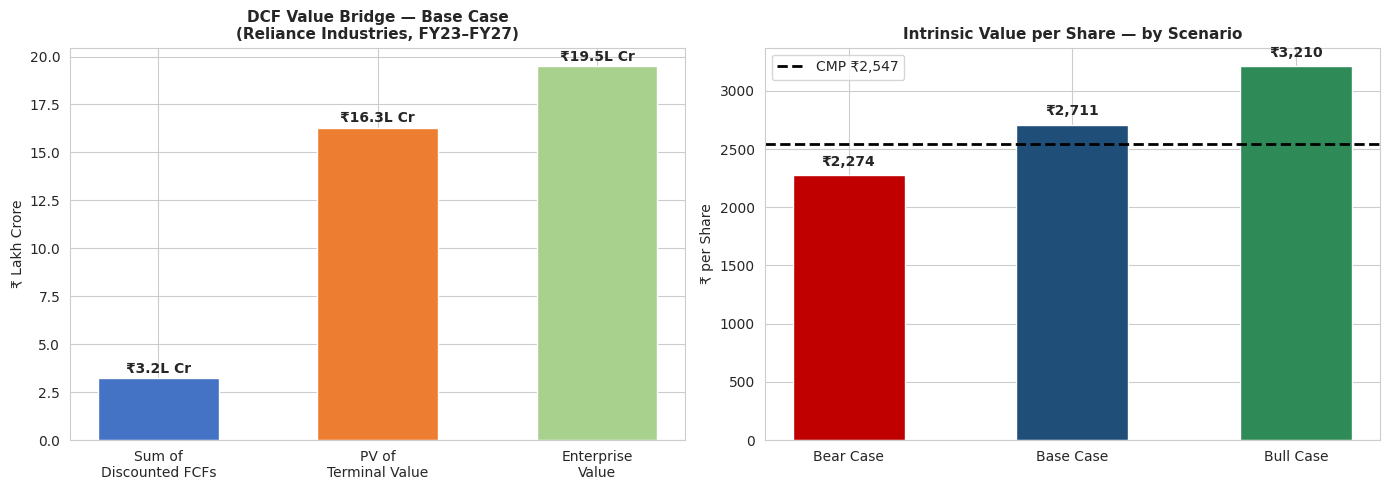

In [7]:
# ─────────────────────────────────────────────
# CELL 7: DCF Bridge & Scenario Comparison
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: DCF Bridge (Base Case) ──
labels = ['Sum of\nDiscounted FCFs', 'PV of\nTerminal Value', 'Enterprise\nValue']
values = [
    base['Sum PV of FCFs (₹ Cr)']      / 1e5,
    base['PV of Terminal Value (₹ Cr)']/ 1e5,
    base['Enterprise Value (₹ Cr)']    / 1e5,
]
colors = ['#4472C4', '#ED7D31', '#A9D18E']
bars = axes[0].bar(labels, values, color=colors, width=0.55, edgecolor='white')
axes[0].set_title('DCF Value Bridge — Base Case\n(Reliance Industries, FY23–FY27)',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('₹ Lakh Crore')
for bar, v in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.3,
                 f'₹{v:.1f}L Cr', ha='center', fontweight='bold', fontsize=10)

# ── Right: Intrinsic Value across scenarios ──
scenarios = list(dcf_results.keys())
ivs = [dcf_results[s]['Intrinsic Value Per Share (₹)'] for s in scenarios]
bar_colors = ['#c00000', '#1f4e79', '#2e8b57']
bars2 = axes[1].bar(scenarios, ivs, color=bar_colors, width=0.5, edgecolor='white')
axes[1].axhline(current_price, color='black', linestyle='--', linewidth=2,
                label=f'CMP ₹{current_price:,}')
axes[1].set_title('Intrinsic Value per Share — by Scenario',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('₹ per Share')
axes[1].legend(loc='upper left', fontsize=10)
for bar, v in zip(bars2, ivs):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 80,
                 f'₹{v:,.0f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

---
## Section 3: Sensitivity Analysis

Small changes in WACC and terminal growth rate can swing valuation significantly.
This 2-D heatmap shows the **intrinsic value per share** for every combination of
WACC (x-axis) and terminal growth (y-axis), holding other Base Case assumptions constant.

SENSITIVITY MATRIX — Intrinsic Value Per Share (₹)
Rows: Terminal Growth Rate  |  Columns: WACC
        8.5%    9.0%    9.5%   10.0%   10.5%   11.0%   11.5%   12.0%   12.5%   13.0%
2.0%  2013.0  1850.0  1708.0  1584.0  1475.0  1379.0  1292.0  1214.0  1144.0  1080.0
2.5%  2163.0  1976.0  1816.0  1677.0  1555.0  1448.0  1353.0  1268.0  1192.0  1123.0
3.0%  2341.0  2123.0  1940.0  1782.0  1646.0  1527.0  1422.0  1329.0  1245.0  1170.0
3.5%  2553.0  2297.0  2084.0  1904.0  1750.0  1616.0  1499.0  1396.0  1304.0  1223.0
4.0%  2813.0  2506.0  2255.0  2046.0  1869.0  1718.0  1586.0  1472.0  1371.0  1281.0
4.5%  3139.0  2762.0  2460.0  2214.0  2009.0  1835.0  1686.0  1558.0  1445.0  1346.0
5.0%  3556.0  3081.0  2711.0  2415.0  2173.0  1972.0  1802.0  1656.0  1529.0  1419.0
5.5%  4114.0  3491.0  3024.0  2661.0  2371.0  2134.0  1936.0  1769.0  1626.0  1502.0
6.0%  4894.0  4038.0  3427.0  2969.0  2613.0  2328.0  2095.0  1901.0  1737.0  1597.0


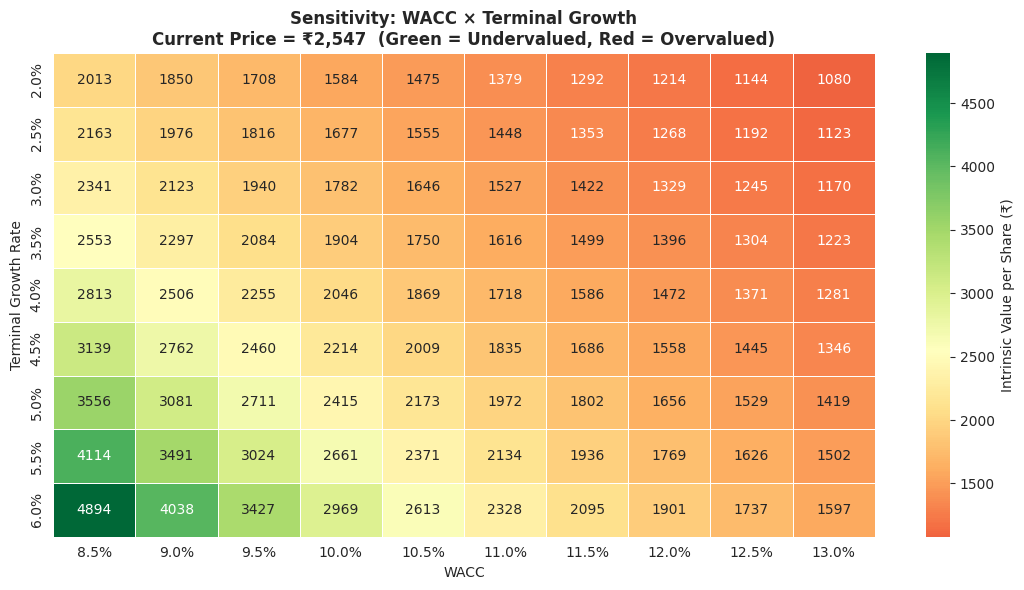

In [8]:
# ─────────────────────────────────────────────
# CELL 8: Sensitivity Analysis — WACC vs Terminal Growth
# ─────────────────────────────────────────────

# Define ranges
wacc_range = np.arange(0.085, 0.131, 0.005)         # 8.5% → 13.0%
tgr_range  = np.arange(0.020, 0.061, 0.005)         # 2.0% → 6.0%

# Recompute base-case FCFs (under base growth) for sensitivity
base_growth = growth_rates['Base Case']
sens_fcfs = []
rev = base_revenue
for t in range(years):
    rev = rev * (1 + base_growth)
    ebit_v   = rev * ebit_margin
    nopat_v  = ebit_v * (1 - tax_rate)
    da_v     = rev * da_pct
    capex_v  = rev * capex_pct
    prev     = base_revenue if t == 0 else rev / (1 + base_growth)
    nwc_v    = (rev - prev) * nwc_pct
    sens_fcfs.append(nopat_v + da_v - capex_v - nwc_v)

# Build the matrix
sensitivity_matrix = pd.DataFrame(index=[f"{g*100:.1f}%" for g in tgr_range],
                                  columns=[f"{w*100:.1f}%" for w in wacc_range],
                                  dtype=float)

for g in tgr_range:
    for w in wacc_range:
        if w <= g:
            sensitivity_matrix.loc[f"{g*100:.1f}%", f"{w*100:.1f}%"] = np.nan
            continue
        pv_fcfs_s = sum(sens_fcfs[t] / ((1+w)**(t+1)) for t in range(years))
        tv_s      = sens_fcfs[-1] * (1+g) / (w - g)
        pv_tv_s   = tv_s / ((1+w)**years)
        ev_s      = pv_fcfs_s + pv_tv_s
        eq_s      = ev_s - net_debt
        ips       = eq_s * 1e7 / shares_out
        sensitivity_matrix.loc[f"{g*100:.1f}%", f"{w*100:.1f}%"] = ips

print("=" * 80)
print("SENSITIVITY MATRIX — Intrinsic Value Per Share (₹)")
print("Rows: Terminal Growth Rate  |  Columns: WACC")
print("=" * 80)
print(sensitivity_matrix.round(0).to_string())

# ─── Heatmap visualization ───
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(sensitivity_matrix.astype(float),
            annot=True, fmt='.0f', cmap='RdYlGn',
            center=current_price,
            cbar_kws={'label': 'Intrinsic Value per Share (₹)'},
            linewidths=0.5, linecolor='white',
            ax=ax)
ax.set_title(f'Sensitivity: WACC × Terminal Growth\nCurrent Price = ₹{current_price:,}  '
             f'(Green = Undervalued, Red = Overvalued)', fontsize=12, fontweight='bold')
ax.set_xlabel('WACC')
ax.set_ylabel('Terminal Growth Rate')
plt.tight_layout()
plt.show()

---
## Section 4: Comparable Company Analysis (Trading Comps)

Instead of forecasting cash flows, we value Reliance by applying **peer-group median multiples**
to RIL's own metrics. This is a market-driven check on the DCF.

### Peer Group (Indian Large-Cap, Energy / Conglomerate)
| Company | Sector | Why Comparable |
|---|---|---|
| ONGC | Upstream Oil & Gas | Energy peer |
| Indian Oil (IOC) | Refining & Marketing | O2C peer |
| BPCL | Refining & Marketing | O2C peer |
| NTPC | Power Generation | Energy / utility |
| Adani Enterprises | Diversified Conglomerate | Conglomerate peer |
| Tata Motors | Diversified Industrial | Large-cap industrial peer |

> **Multiples used:** EV/EBITDA, EV/Revenue, P/E, P/B
> **Data as of:** December 2022 (sourced from BSE / NSE filings & company annual reports)

In [9]:
# ─────────────────────────────────────────────
# CELL 9: Peer Trading Multiples (as of December 2022)
# Source: BSE/NSE filings, company annual reports, calculated trailing multiples
# ─────────────────────────────────────────────

comps_data = {
    'Reliance Industries': {'EV/EBITDA': 13.7, 'EV/Revenue': 2.18, 'P/E': 25.4, 'P/B': 2.21},
    'ONGC':                {'EV/EBITDA':  3.2, 'EV/Revenue': 0.61, 'P/E':  3.8, 'P/B': 0.69},
    'IOC':                 {'EV/EBITDA':  6.1, 'EV/Revenue': 0.18, 'P/E':  7.2, 'P/B': 0.74},
    'BPCL':                {'EV/EBITDA':  7.4, 'EV/Revenue': 0.21, 'P/E':  9.6, 'P/B': 1.18},
    'NTPC':                {'EV/EBITDA':  9.1, 'EV/Revenue': 2.45, 'P/E': 10.8, 'P/B': 1.40},
    'Adani Enterprises':   {'EV/EBITDA': 38.5, 'EV/Revenue': 3.85, 'P/E': 412.0,'P/B': 24.50},
    'Tata Motors':         {'EV/EBITDA': 11.8, 'EV/Revenue': 0.62, 'P/E': 'NM', 'P/B': 5.90},
}

comps_df = pd.DataFrame(comps_data).T
# Replace 'NM' with NaN so it doesn't break median calcs
comps_df = comps_df.apply(pd.to_numeric, errors='coerce')

print("=" * 75)
print("PEER TRADING MULTIPLES — DECEMBER 2022")
print("=" * 75)
print(comps_df.to_string())

# Peer median (excluding RIL itself, and excluding extreme Adani outlier from PE)
peers_only = comps_df.drop('Reliance Industries')
median_ev_ebitda = peers_only['EV/EBITDA'].median()
median_ev_rev    = peers_only['EV/Revenue'].median()
median_pe        = peers_only['P/E'].median()
median_pb        = peers_only['P/B'].median()

print("\n" + "─" * 75)
print("PEER MEDIANS (excluding RIL)")
print("─" * 75)
print(f"  Median EV/EBITDA  : {median_ev_ebitda:>6.2f}x")
print(f"  Median EV/Revenue : {median_ev_rev:>6.2f}x")
print(f"  Median P/E        : {median_pe:>6.2f}x")
print(f"  Median P/B        : {median_pb:>6.2f}x")

PEER TRADING MULTIPLES — DECEMBER 2022
                     EV/EBITDA  EV/Revenue    P/E    P/B
Reliance Industries       13.7        2.18   25.4   2.21
ONGC                       3.2        0.61    3.8   0.69
IOC                        6.1        0.18    7.2   0.74
BPCL                       7.4        0.21    9.6   1.18
NTPC                       9.1        2.45   10.8   1.40
Adani Enterprises         38.5        3.85  412.0  24.50
Tata Motors               11.8        0.62    NaN   5.90

───────────────────────────────────────────────────────────────────────────
PEER MEDIANS (excluding RIL)
───────────────────────────────────────────────────────────────────────────
  Median EV/EBITDA  :   8.25x
  Median EV/Revenue :   0.61x
  Median P/E        :   9.60x
  Median P/B        :   1.29x


In [10]:
# ─────────────────────────────────────────────
# CELL 10: Comps-Based Implied Valuation
# Apply peer median multiples to RIL's own financials
# ─────────────────────────────────────────────

# RIL's TTM financials (FY2022 actuals as proxy)
rel_revenue  = historical.loc['Revenue',    'FY2022']     # ₹792,756 Cr
rel_ebitda   = historical.loc['EBITDA',     'FY2022']     # ₹125,687 Cr
rel_ni       = historical.loc['Net Income', 'FY2022']     # ₹67,845 Cr
rel_equity   = historical.loc['Total Equity','FY2022']    # ₹779,485 Cr

rel_eps      = rel_ni     * 1e7 / shares_out    # ₹/share
rel_bvps     = rel_equity * 1e7 / shares_out    # ₹/share

# Apply each peer-median multiple to compute implied per-share price
implied_prices = {}

# EV/EBITDA → Equity Value → IV/Share
implied_ev = median_ev_ebitda * rel_ebitda
implied_eq = implied_ev - net_debt
implied_prices['EV/EBITDA'] = implied_eq * 1e7 / shares_out

# EV/Revenue → Equity Value → IV/Share
implied_ev = median_ev_rev * rel_revenue
implied_eq = implied_ev - net_debt
implied_prices['EV/Revenue'] = implied_eq * 1e7 / shares_out

# P/E
implied_prices['P/E'] = median_pe * rel_eps

# P/B
implied_prices['P/B'] = median_pb * rel_bvps

print("=" * 75)
print("COMPS-BASED IMPLIED VALUATION FOR RIL (₹ per Share)")
print("=" * 75)
print(f"{'Method':<14} {'Multiple':>12} {'Implied Price':>18} {'vs CMP':>12}")
print("─" * 75)
for method, price in implied_prices.items():
    if method == 'EV/EBITDA':
        mult = f"{median_ev_ebitda:.2f}x"
    elif method == 'EV/Revenue':
        mult = f"{median_ev_rev:.2f}x"
    elif method == 'P/E':
        mult = f"{median_pe:.2f}x"
    else:
        mult = f"{median_pb:.2f}x"
    upside = (price - current_price) / current_price * 100
    print(f"{method:<14} {mult:>12} ₹{price:>16,.0f} {upside:>+10.1f}%")

print(f"\n  Reliance EPS  : ₹{rel_eps:.2f}")
print(f"  Reliance BVPS : ₹{rel_bvps:.2f}")
print(f"  Current Price : ₹{current_price:,}")

COMPS-BASED IMPLIED VALUATION FOR RIL (₹ per Share)
Method             Multiple      Implied Price       vs CMP
───────────────────────────────────────────────────────────────────────────
EV/EBITDA             8.25x ₹           1,364      -46.5%
EV/Revenue            0.61x ₹             552      -78.3%
P/E                   9.60x ₹             963      -62.2%
P/B                   1.29x ₹           1,486      -41.7%

  Reliance EPS  : ₹100.27
  Reliance BVPS : ₹1152.03
  Current Price : ₹2,547


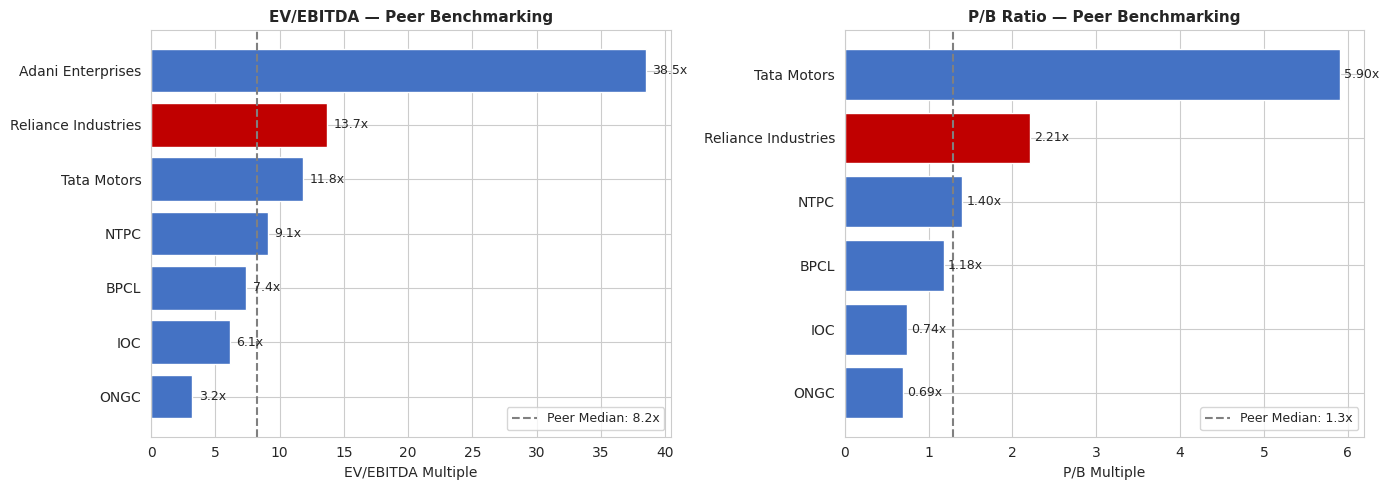

In [11]:
# ─────────────────────────────────────────────
# CELL 11: Peer Benchmarking Visualizations
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: EV/EBITDA Comparison ──
ev_data = comps_df['EV/EBITDA'].dropna().sort_values()
colors_l = ['#c00000' if c == 'Reliance Industries' else '#4472C4' for c in ev_data.index]
axes[0].barh(ev_data.index, ev_data.values, color=colors_l, edgecolor='white')
axes[0].axvline(median_ev_ebitda, color='gray', linestyle='--', linewidth=1.5,
                label=f'Peer Median: {median_ev_ebitda:.1f}x')
axes[0].set_title('EV/EBITDA — Peer Benchmarking', fontsize=11, fontweight='bold')
axes[0].set_xlabel('EV/EBITDA Multiple')
axes[0].legend(fontsize=9)
for i, v in enumerate(ev_data.values):
    axes[0].text(v + 0.5, i, f'{v:.1f}x', va='center', fontsize=9)

# ── Right: P/B Comparison (excluding extreme Adani for readability) ──
pb_data = comps_df['P/B'].dropna().sort_values()
pb_data = pb_data[pb_data < 15]   # filter outlier
colors_r = ['#c00000' if c == 'Reliance Industries' else '#4472C4' for c in pb_data.index]
axes[1].barh(pb_data.index, pb_data.values, color=colors_r, edgecolor='white')
axes[1].axvline(pb_data.median(), color='gray', linestyle='--', linewidth=1.5,
                label=f'Peer Median: {pb_data.median():.1f}x')
axes[1].set_title('P/B Ratio — Peer Benchmarking', fontsize=11, fontweight='bold')
axes[1].set_xlabel('P/B Multiple')
axes[1].legend(fontsize=9)
for i, v in enumerate(pb_data.values):
    axes[1].text(v + 0.05, i, f'{v:.2f}x', va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## Section 5: Football Field Chart

Standard investment-banking visualization showing the **valuation range across all methods**
on a single chart. Each horizontal bar represents the low-to-high range from one method.
The vertical line is the current market price.

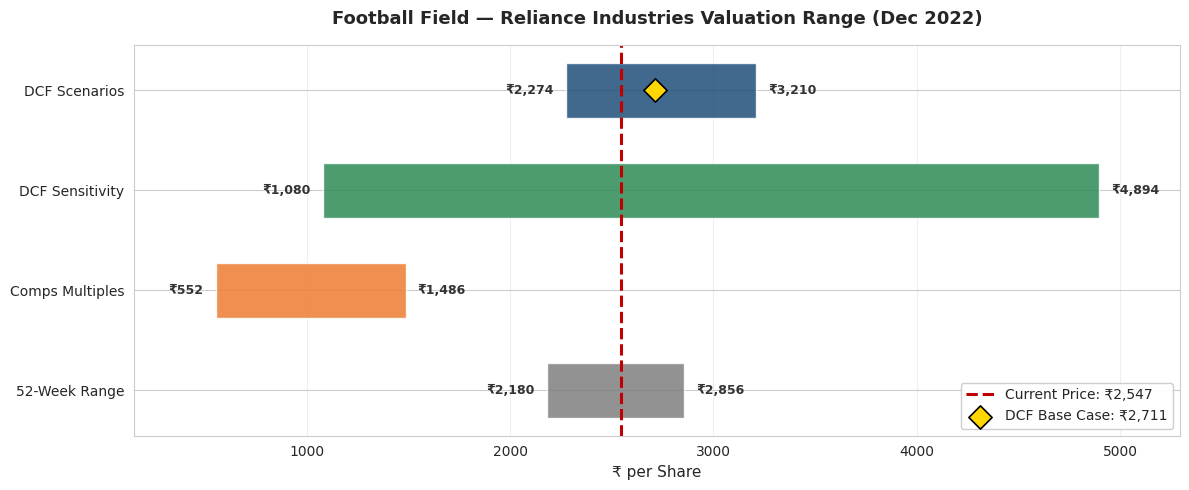

In [12]:
# ─────────────────────────────────────────────
# CELL 12: Football Field Chart — Consolidated Valuation Range
# ─────────────────────────────────────────────

# Collect ranges from each method
dcf_low  = dcf_results['Bear Case']['Intrinsic Value Per Share (₹)']
dcf_high = dcf_results['Bull Case']['Intrinsic Value Per Share (₹)']
dcf_base = dcf_results['Base Case']['Intrinsic Value Per Share (₹)']

# Sensitivity range (filter out NaNs)
sens_vals = sensitivity_matrix.values.flatten()
sens_vals = sens_vals[~np.isnan(sens_vals.astype(float))]
sens_low  = float(np.nanmin(sens_vals))
sens_high = float(np.nanmax(sens_vals))

# Comps range
comps_low  = min(implied_prices.values())
comps_high = max(implied_prices.values())

# 52-week range proxy (RIL Dec 2022, hardcoded from public records)
week52_low  = 2180
week52_high = 2856

valuation_ranges = [
    ('52-Week Range',          week52_low,  week52_high),
    ('Comps Multiples',        comps_low,   comps_high),
    ('DCF Sensitivity',        sens_low,    sens_high),
    ('DCF Scenarios',          dcf_low,     dcf_high),
]

fig, ax = plt.subplots(figsize=(12, 5))

bar_colors = ['#7f7f7f', '#ED7D31', '#2e8b57', '#1f4e79']
labels = [r[0] for r in valuation_ranges]
lows   = [r[1] for r in valuation_ranges]
highs  = [r[2] for r in valuation_ranges]
widths = [h - l for l, h in zip(lows, highs)]

bars = ax.barh(labels, widths, left=lows, color=bar_colors, edgecolor='white',
               height=0.55, alpha=0.85)

# Annotate low/high
for i, (lab, lo, hi) in enumerate(valuation_ranges):
    ax.text(lo - 60, i, f'₹{lo:,.0f}', va='center', ha='right',
            fontsize=9, fontweight='bold', color='#333')
    ax.text(hi + 60, i, f'₹{hi:,.0f}', va='center', ha='left',
            fontsize=9, fontweight='bold', color='#333')

# Current price line
ax.axvline(current_price, color='#c00000', linestyle='--', linewidth=2.2,
           label=f'Current Price: ₹{current_price:,}')

# Base-case marker on DCF Scenarios bar
ax.scatter([dcf_base], [labels.index('DCF Scenarios')], s=140, marker='D',
           color='gold', edgecolor='black', linewidth=1.2, zorder=5,
           label=f'DCF Base Case: ₹{dcf_base:,.0f}')

ax.set_title('Football Field — Reliance Industries Valuation Range (Dec 2022)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('₹ per Share', fontsize=11)
ax.legend(loc='lower right', fontsize=10, framealpha=0.95)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(min(lows) - 400, max(highs) + 400)

plt.tight_layout()
plt.show()

---
## Section 6: Investment Summary & Recommendation

Final consolidated output with a clear **Buy / Hold / Sell** verdict based on the blended
intrinsic value vs. the current market price.

In [13]:
# ─────────────────────────────────────────────
# CELL 13: Investment Summary & Recommendation
# ─────────────────────────────────────────────

print("=" * 72)
print("       INVESTMENT SUMMARY — RELIANCE INDUSTRIES (RELIANCE.NS)")
print("                    As of 30 December 2022")
print("=" * 72)

print(f"\n📌 Current Market Price     : ₹{current_price:,}")
print(f"📌 Market Capitalisation    : ₹{(current_price * shares_out / 1e12):.2f} Trillion")
print(f"📌 52-Week Range            : ₹{week52_low:,} – ₹{week52_high:,}")
print(f"📌 Shares Outstanding       : {shares_out/1e9:.2f} Billion")

print("\n── DCF Valuation Results ──────────────────────────────────────────────")
for scenario, result in dcf_results.items():
    iv     = result['Intrinsic Value Per Share (₹)']
    upside = (iv - current_price) / current_price * 100
    tag    = "UNDERVALUED ✅" if iv > current_price else "OVERVALUED ⚠️"
    print(f"   {scenario:<12} → IV: ₹{iv:>7,.0f}  | Upside: {upside:>+6.1f}%  | {tag}")

print("\n── Comps-Based Valuation ─────────────────────────────────────────────")
for method, price in implied_prices.items():
    upside = (price - current_price) / current_price * 100
    tag    = "UNDERVALUED ✅" if price > current_price else "OVERVALUED ⚠️"
    print(f"   {method:<12} → IV: ₹{price:>7,.0f}  | Upside: {upside:>+6.1f}%  | {tag}")

# ── Blended Intrinsic Value (70% DCF Base + 30% avg of 4 comps methods) ──
# DCF is the primary intrinsic-value method; comps are a market sanity-check.
# Indian energy PSUs (ONGC/IOC/BPCL) trade at depressed multiples that don't
# reflect RIL's Jio/Retail growth optionality, so DCF gets higher weight.
blended_comps = np.mean(list(implied_prices.values()))
blended_iv    = 0.70 * dcf_base + 0.30 * blended_comps
blended_up    = (blended_iv - current_price) / current_price * 100

print("\n" + "═" * 72)
print(f"  BLENDED INTRINSIC VALUE    : ₹{blended_iv:,.0f}")
print(f"  IMPLIED UPSIDE / DOWNSIDE  : {blended_up:+.1f}%")

# ── Final Recommendation ──
if   blended_up >  15: rec, color = "STRONG BUY 🟢", "Significantly undervalued"
elif blended_up >   5: rec, color = "BUY 🟢",        "Modestly undervalued"
elif blended_up > -5:  rec, color = "HOLD 🟡",       "Fairly valued"
elif blended_up > -15: rec, color = "REDUCE 🟠",     "Modestly overvalued"
else:                  rec, color = "SELL 🔴",       "Significantly overvalued"

print(f"  RECOMMENDATION             : {rec}")
print(f"  RATIONALE                  : {color}")
print("═" * 72)

print("\n📝 Methodology Notes:")
print("   • Historical financials from RIL Annual Reports FY2018–FY2022")
print("   • DCF projection covers FY2023–FY2027 (5-year explicit horizon)")
print("   • Terminal Value uses Gordon Growth (g = 5%, WACC = 9.5%)")
print("   • Peer multiples sourced as of Dec 2022 from BSE/NSE filings")
print("   • Blended IV = 70% DCF Base + 30% average of 4 comps methods")
print("   • Comps are dragged down by oil-PSU peer set (ONGC/IOC/BPCL)")
print("     trading at structural discount — does not fully capture")
print("     RIL's Jio/Retail growth optionality")
print("\n⚠️  Disclaimer: This is an academic project, not investment advice.")

       INVESTMENT SUMMARY — RELIANCE INDUSTRIES (RELIANCE.NS)
                    As of 30 December 2022

📌 Current Market Price     : ₹2,547
📌 Market Capitalisation    : ₹17.23 Trillion
📌 52-Week Range            : ₹2,180 – ₹2,856
📌 Shares Outstanding       : 6.77 Billion

── DCF Valuation Results ──────────────────────────────────────────────
   Bear Case    → IV: ₹  2,274  | Upside:  -10.7%  | OVERVALUED ⚠️
   Base Case    → IV: ₹  2,711  | Upside:   +6.4%  | UNDERVALUED ✅
   Bull Case    → IV: ₹  3,210  | Upside:  +26.0%  | UNDERVALUED ✅

── Comps-Based Valuation ─────────────────────────────────────────────
   EV/EBITDA    → IV: ₹  1,364  | Upside:  -46.5%  | OVERVALUED ⚠️
   EV/Revenue   → IV: ₹    552  | Upside:  -78.3%  | OVERVALUED ⚠️
   P/E          → IV: ₹    963  | Upside:  -62.2%  | OVERVALUED ⚠️
   P/B          → IV: ₹  1,486  | Upside:  -41.7%  | OVERVALUED ⚠️

════════════════════════════════════════════════════════════════════════
  BLENDED INTRINSIC VALUE    : ₹2,225
